In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import config as cfg
import data_loader as dl

pd.set_option("display.max_columns", None)

In [2]:
ticker = "RELIANCE"
df = dl.load_stock(ticker)

print(f"{ticker}: {df.shape[0]} rows, {df.index.min().date()} -> {df.index.max().date()}")
print(f"Split flags: {int(df['split_flag'].sum())}")
print("\nMissing values per column:")
print(df.isna().sum())

df[["Open", "High", "Low", "Close", "VWAP", "Volume", "%Deliverble"]].describe()

RELIANCE: 5306 rows, 2000-01-03 -> 2021-04-30
Split flags: 2

Missing values per column:
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     514
%Deliverble            514
ticker                   0
split_flag               0
dtype: int64


,Open,High,Low,Close,VWAP,Volume,%Deliverble
count,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5.306000e+03,4792.000000
mean,1012.602375,1026.823803,996.886977,1011.316839,1011.937409,5.583028e+06,0.435039
std,572.575893,581.986757,560.703328,571.046753,571.222520,4.983793e+06,0.144722
min,205.500000,219.500000,197.150000,203.200000,212.290000,5.282000e+04,0.076300
25%,572.925000,582.950000,564.237500,572.512500,573.190000,2.836454e+06,0.323325
50%,939.000000,950.075000,927.550000,938.275000,939.785000,4.213432e+06,0.449450
75%,1247.675000,1267.350000,1227.450000,1248.275000,1247.375000,6.602604e+06,0.544300
max,3298.000000,3298.000000,3141.300000,3220.850000,3197.750000,6.523089e+07,0.978300


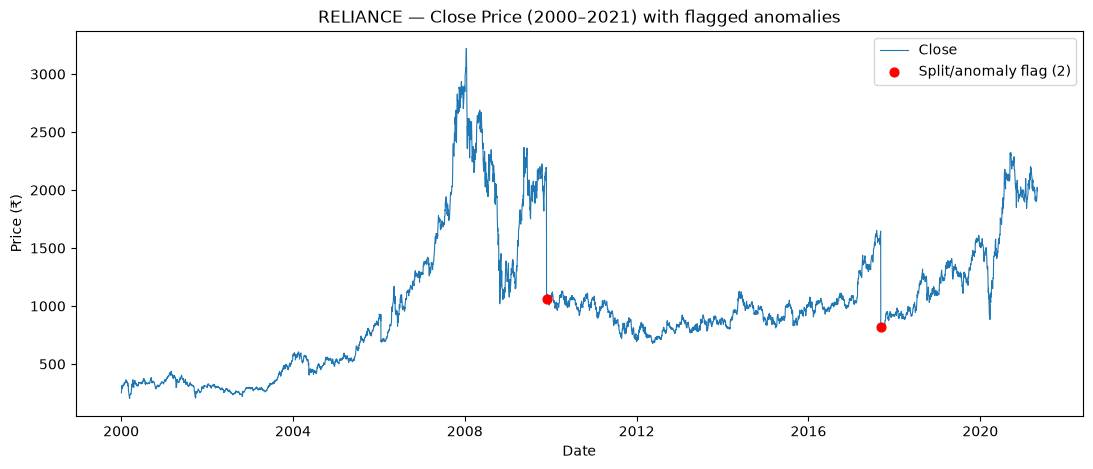

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df["Close"], lw=0.8, label="Close")

# Mark the days our split detector flagged
flagged = df[df["split_flag"]]
ax.scatter(flagged.index, flagged["Close"], color="red", s=40,
           zorder=5, label=f"Split/anomaly flag ({len(flagged)})")

ax.set_title(f"{ticker} — Close Price (2000–2021) with flagged anomalies")
ax.set_xlabel("Date")
ax.set_ylabel("Price (₹)")
ax.legend()
plt.show()

In [5]:
# Daily log returns, with split days neutralized so they don't appear as fake -50% crashes in the distribution.
def compute_returns(df, price_col="Close", neutralize_splits=True):
    ret = np.log(df[price_col] / df[price_col].shift(1))
    if neutralize_splits and "split_flag" in df.columns:
        ret[df["split_flag"]] = np.nan   # drop the artifact days
    return ret

df["log_ret"] = compute_returns(df)

print("Daily log return stats (RELIANCE):")
print(df["log_ret"].describe())
print(f"\nAnnualized volatility: {df['log_ret'].std() * np.sqrt(cfg.TRADING_DAYS):.1%}")
print(f"Annualized mean return: {df['log_ret'].mean() * cfg.TRADING_DAYS:.1%}")

Daily log return stats (RELIANCE):
count    5303.000000
mean        0.000659
std         0.021966
min        -0.291531
25%        -0.010661
50%         0.000563
75%         0.011825
max         0.193667
Name: log_ret, dtype: float64

Annualized volatility: 34.9%
Annualized mean return: 16.6%


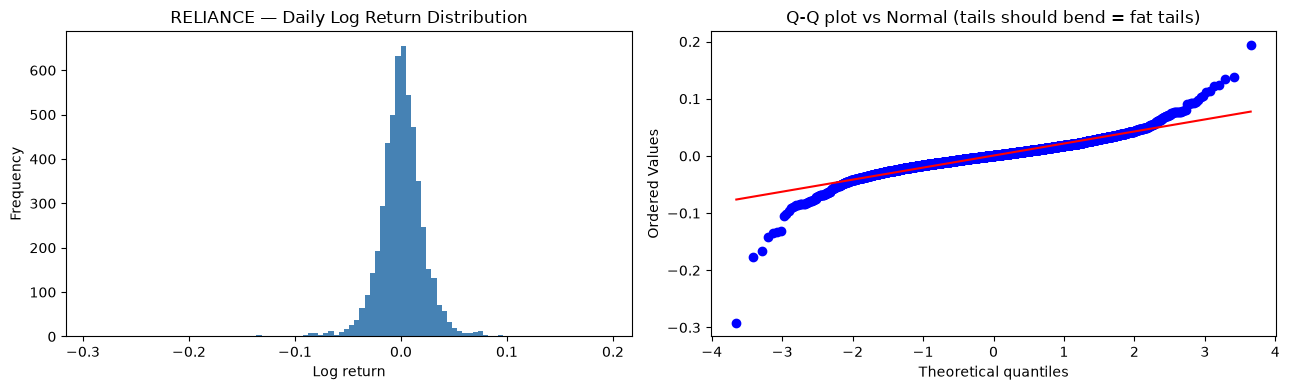

Skew: -0.50   Kurtosis: 12.09  (normal=0)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["log_ret"].dropna(), bins=100, color="steelblue", edgecolor="none")
axes[0].set_title(f"{ticker} — Daily Log Return Distribution")
axes[0].set_xlabel("Log return"); axes[0].set_ylabel("Frequency")

# Compare to a normal distribution — markets have FAT TAILS
from scipy import stats
r = df["log_ret"].dropna()
stats.probplot(r, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot vs Normal (tails should bend = fat tails)")

plt.tight_layout(); plt.show()

print(f"Skew: {r.skew():.2f}   Kurtosis: {r.kurtosis():.2f}  (normal=0)")

In [7]:
# Wide panel of daily log returns across all stocks (split-neutralized).
def build_returns_panel(tickers=None):
    if tickers is None:
        tickers = dl.list_tickers()
    rets = {}
    for t in tickers:
        d = dl.load_stock(t) # has split_flag
        rets[t] = compute_returns(d) # split-neutralized log returns
    return pd.DataFrame(rets).sort_index()

ret_panel = build_returns_panel()
print("Returns panel shape:", ret_panel.shape)
print("Date range:", ret_panel.index.min().date(), "->", ret_panel.index.max().date())

# Annualized risk/return per stock
annual = pd.DataFrame({
    "ann_return": ret_panel.mean() * cfg.TRADING_DAYS,
    "ann_vol":    ret_panel.std()  * np.sqrt(cfg.TRADING_DAYS),
})
annual["return_per_risk"] = annual["ann_return"] / annual["ann_vol"]
annual.sort_values("return_per_risk", ascending=False).head(10)

Returns panel shape: (5306, 50)
Date range: 2000-01-03 -> 2021-04-30


,ann_return,ann_vol,return_per_risk
ASIANPAINT,0.243648,0.271842,0.896284
SHREECEM,0.306719,0.387686,0.791155
BAJFINANCE,0.335117,0.441464,0.759105
NESTLEIND,0.168681,0.241459,0.698593
EICHERMOT,0.294255,0.43386,0.678226
KOTAKBANK,0.296583,0.441363,0.671972
HDFCBANK,0.209528,0.319036,0.656755
BAJAJ-AUTO,0.200976,0.307692,0.653175
BRITANNIA,0.174615,0.268496,0.650343
TCS,0.197062,0.308032,0.639747


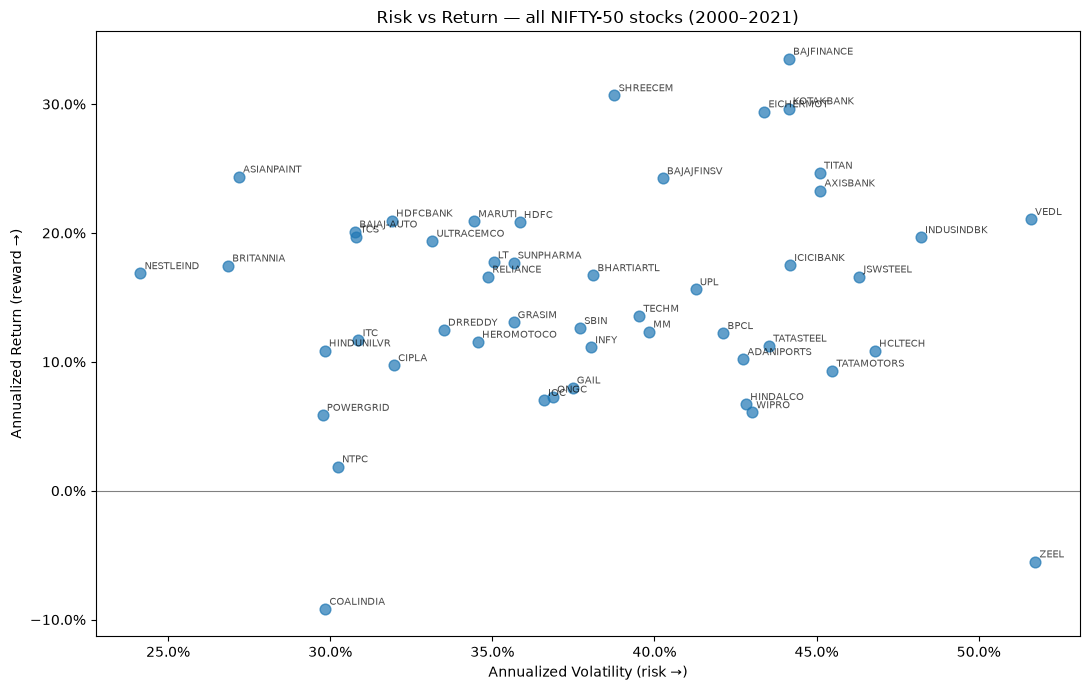

In [8]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(annual["ann_vol"], annual["ann_return"], s=60, alpha=0.7)

for t in annual.index:
    ax.annotate(t, (annual.loc[t, "ann_vol"], annual.loc[t, "ann_return"]),
                fontsize=7, alpha=0.7,
                xytext=(3, 3), textcoords="offset points")

ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("Annualized Volatility (risk →)")
ax.set_ylabel("Annualized Return (reward →)")
ax.set_title("Risk vs Return — all NIFTY-50 stocks (2000–2021)")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout(); plt.show()

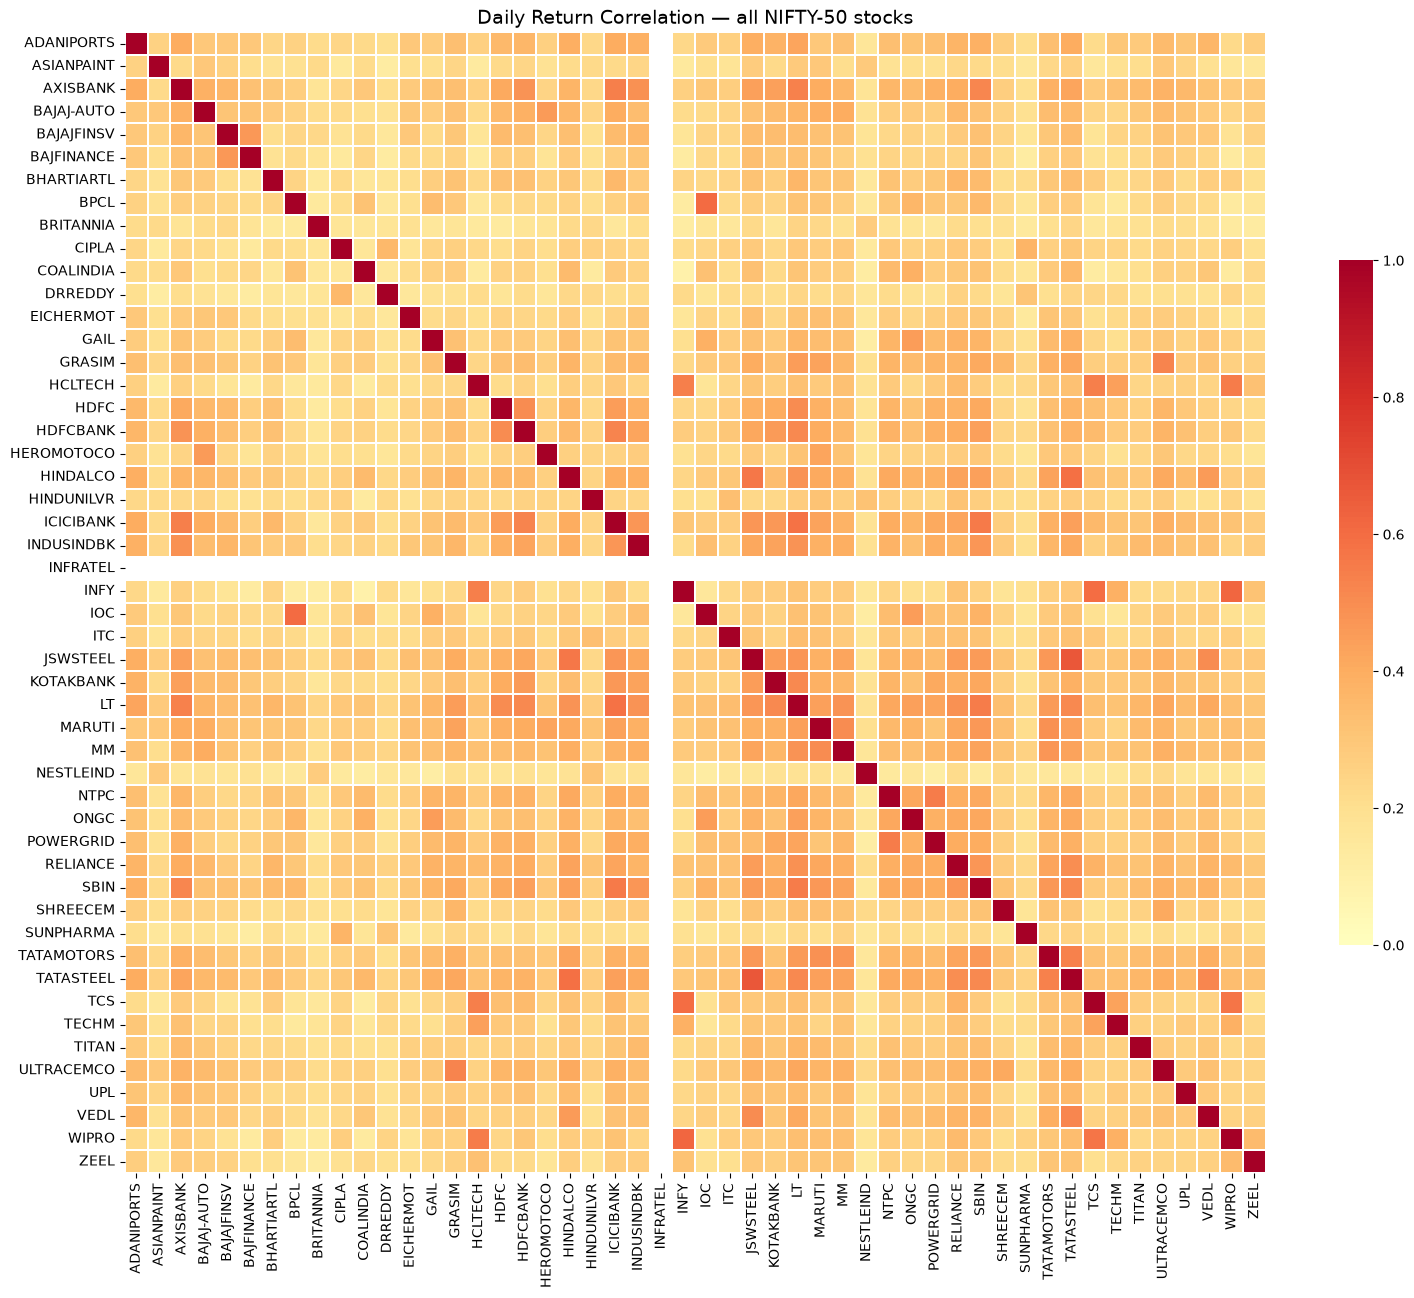

LEAST correlated pairs (best diversifiers):
COALINDIA  INFY         0.091060
INFY       COALINDIA    0.091060
POWERGRID  NESTLEIND    0.111345
NESTLEIND  POWERGRID    0.111345
           GAIL         0.114056
dtype: float64

MOST correlated pairs (move together):
JSWSTEEL   TATASTEEL    0.666731
TATASTEEL  JSWSTEEL     0.666731
WIPRO      INFY         0.618927
INFY       WIPRO        0.618927
IOC        BPCL         0.604380
dtype: float64


In [9]:
# Correlation of daily returns across all stocks
corr = ret_panel.corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr, cmap="RdYlBu_r", center=0, vmin=0, vmax=1,
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.6},
            annot=False, ax=ax)
ax.set_title("Daily Return Correlation — all NIFTY-50 stocks", fontsize=14)
plt.tight_layout(); plt.show()

# Most & least correlated pairs (diversification candidates)
c = corr.where(~np.eye(len(corr), dtype=bool))   # drop the diagonal
pairs = c.unstack().dropna().sort_values()
print("LEAST correlated pairs (best diversifiers):")
print(pairs.head(5))
print("\nMOST correlated pairs (move together):")
print(pairs.tail(5).iloc[::-1])

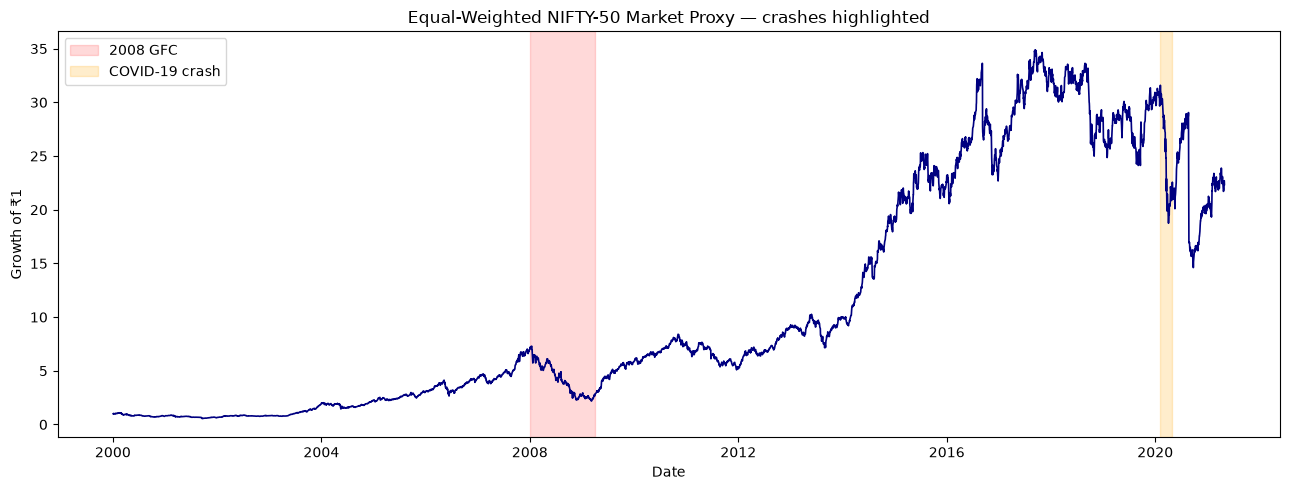

In [ ]:
# Equal-weighted "market" index from our stocks
norm_prices = dl.load_price_panel().ffill().dropna(how="all")
market = norm_prices.div(norm_prices.iloc[0]).mean(axis=1)   # avg normalized price

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(market.index, market.values, lw=1.2, color="navy")
ax.set_title("Equal-Weighted NIFTY-50 Market Proxy — crashes highlighted")
ax.set_ylabel("Growth of ₹1"); ax.set_xlabel("Date")

# Shade the two major crashes
ax.axvspan(pd.Timestamp("2008-01-01"), pd.Timestamp("2009-03-31"),
           color="red", alpha=0.15, label="2008 GFC")
ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-04-30"),
           color="orange", alpha=0.20, label="COVID-19 crash")

ax.legend()
plt.tight_layout()
plt.show()